# Mixed Precision Error Audit for `calculate_synaptic_currents`

This notebook measures numerical error introduced by mixed precision (`float16` compute, `float32` variables) versus pure `float32`, using **actual network parameters** loaded from your V1 data.

It includes two analyses:
1. **Operator-level**: forward current and custom-gradient errors in `calculate_synaptic_currents`.
2. **BPTT-level**: error growth across truncation windows (sequence length sweep), comparing losses/states/gradients.

The code disables background Poisson noise for strict A/B reproducibility, so differences come from numeric precision only.


In [1]:
import importlib
import os
import glob
import pickle as pkl
from types import SimpleNamespace
import types

# Must be set before importing TensorFlow.
os.environ['CUDA_VISIBLE_DEVICES'] = '0'

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import mixed_precision

# Keep only GPU:0 visible to TensorFlow.
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    tf.config.set_visible_devices(gpus[0], 'GPU')
    try:
        tf.config.experimental.set_memory_growth(gpus[0], True)
    except Exception:
        pass

from v1_model_utils import load_sparse, models
models = importlib.reload(models)

np.set_printoptions(suppress=True, precision=6)
pd.set_option('display.max_rows', 200)
print('TensorFlow:', tf.__version__)
print('Visible GPUs:', tf.config.list_physical_devices('GPU'))



/tmp/ipykernel_13879/434434932.py:12: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd
2026-02-12 10:53:11.636008: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-12 10:53:12.736308: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-02-12 10:53

TensorFlow: 2.15.0
Visible GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# Configuration
CONFIG = {
    # Try these in order; first with network/v1_nodes.h5 is selected.
    'data_dir_candidates': [
        # 'GLIF_network',
        # 'GLIF_network_nll',
        # 'GLIF_network_nll_core',
        'GLIF_network_nll_full',
    ],

    # Real network subset size (actual network parameters from cache/data files).
    'neurons': 66652,
    'n_input': 17400,
    'batch_size': 1,
    'seed': 3000,

    # Cell parameters aligned with training defaults where relevant.
    'gauss_std': 0.3,
    'dampening_factor': 0.1,
    'recurrent_dampening_factor': 0.1,
    'input_weight_scale': 1.0,
    'lr_scale': 1.0,

    # Input generation
    # 'bernoulli_uniform' uses a fixed Bernoulli rate.
    # 'spontaneous_cached' uses cached spontaneous LGN probabilities if available.
    'input_mode': 'bernoulli_uniform',
    'input_spike_prob': 0.02,

    # Operator test settings
    'op_warmup_steps': 30,

    # BPTT sweep (truncation windows)
    'bptt_seq_lengths': [20, 500],

    # Probe loss: alpha*mean(spikes) + beta*mean(v^2)
    'loss_alpha': 1.0,
    'loss_beta': 0.01,

    # Mixed precision gradient audit settings
    # In training, float16 typically uses dynamic loss scaling. Include a fixed-scale path here.
    'evaluate_fp16_with_loss_scaling': True,
    'fp16_loss_scale': 32768.0,

    # Metric stability
    'sign_atol': 1e-10,
    'rel_eps': 1e-12,
}

def pick_data_dir(candidates):
    for d in candidates:
        if os.path.isfile(os.path.join(d, 'network', 'v1_nodes.h5')):
            return d
    raise FileNotFoundError('No candidate data_dir has network/v1_nodes.h5')

DATA_DIR = pick_data_dir(CONFIG['data_dir_candidates'])
print('Using data_dir:', DATA_DIR)

# Global seeding for reproducibility
np.random.seed(CONFIG['seed'])
tf.random.set_seed(CONFIG['seed'])



Using data_dir: GLIF_network_nll_full


In [3]:
# Build a minimal flags object compatible with load_sparse.cached_load_v1
flags = SimpleNamespace(
    data_dir=DATA_DIR,
    core_only=False,
    neurons=CONFIG['neurons'],
    seed=CONFIG['seed'],
    connected_selection=True,
    random_weights=False,
    uniform_weights=False,
    n_input=CONFIG['n_input'],
    n_output=2,
    neurons_per_output=16,
    loss_core_radius=400.0,
)

network, lgn_input, bkg_input = load_sparse.cached_load_v1(
    flags=flags,
    n_neurons=flags.neurons,
    flag_str=f'v1_{flags.neurons}',
)

print('Loaded network:')
print('  n_nodes:', network['n_nodes'])
print('  n_edges:', network['n_edges'])
print('  lgn n_input:', lgn_input['n_inputs'])
print('  bkg n_input:', bkg_input['n_inputs'])


> Looking for cached V1 model in GLIF_network_nll_full/tf_data/V1_network_v1_66652.pkl
> Sucessfully restored V1 model from GLIF_network_nll_full/tf_data/V1_network_v1_66652.pkl
Loaded network:
  n_nodes: 66652
  n_edges: 24088502
  lgn n_input: 17400
  bkg n_input: 100


In [4]:
def build_cell(policy_name, network, lgn_input, bkg_input, cfg):
    mixed_precision.set_global_policy(policy_name)
    cell = models.V1Column(
        network=network,
        lgn_input=lgn_input,
        bkg_input=bkg_input,
        dt=1.0,
        gauss_std=cfg['gauss_std'],
        dampening_factor=cfg['dampening_factor'],
        recurrent_dampening_factor=cfg['recurrent_dampening_factor'],
        input_weight_scale=cfg['input_weight_scale'],
        recurrent_weight_scale=1.0,
        lr_scale=cfg['lr_scale'],
        spike_gradient=False,
        max_delay=5,
        batch_size=cfg['batch_size'],
        bkg_firing_rate=250,
        pseudo_gauss=False,
        train_recurrent=True,
        train_recurrent_per_type=False,
        train_input=False,
        train_noise=False,
        hard_reset=False,
        current_input=False,
    )
    # Disable stochastic background noise to isolate precision effects only.
    cell.bkg_spike_prob = tf.constant(0.0, dtype=cell.compute_dtype)
    return cell


def align_cell_variables(src_cell, dst_cell):
    # Force identical variable values across precision paths before comparisons.
    src_w = list(src_cell.weights)
    dst_w = list(dst_cell.weights)

    if len(src_w) != len(dst_w):
        print(f'Warning: different number of weights src={len(src_w)} dst={len(dst_w)}')

    n = min(len(src_w), len(dst_w))
    mismatched_shapes = []
    for i in range(n):
        s = src_w[i]
        d = dst_w[i]
        if tuple(s.shape) != tuple(d.shape):
            mismatched_shapes.append((i, s.name, tuple(s.shape), d.name, tuple(d.shape)))
            continue
        d.assign(tf.cast(s, d.dtype))

    if mismatched_shapes:
        print('Warning: shape mismatches during alignment:', len(mismatched_shapes))
        for item in mismatched_shapes[:5]:
            print('  idx', item[0], '|', item[1], item[2], '->', item[3], item[4])


def patch_input_current_dtype_safe(cell):
    """Notebook-only patch: keep mixed-precision multiply dtype-consistent.

    This avoids fp32*fp16 Mul errors in calculate_input_current_from_spikes
    without modifying models.py.
    """
    def _safe_calculate_input_current_from_spikes(self, x_t):
        batch_size = tf.cast(tf.shape(x_t)[0], dtype=tf.int64)
        n_post_neurons = self.lgn_input_dense_shape[0]

        if x_t.dtype == tf.bool:
            non_zero_indices = tf.where(x_t)
        else:
            non_zero_indices = tf.where(x_t > 0)

        batch_indices = non_zero_indices[:, 0]
        pre_neuron_indices = non_zero_indices[:, 1]

        new_indices, new_weights, new_syn_ids, post_in_degree, _ = models.get_new_inds_table(
            self.input_indices,
            self.input_weight_values,
            self.input_syn_ids,
            pre_neuron_indices,
            self.pre_input_ind_table,
        )

        batch_indices_per_connection = tf.repeat(batch_indices, post_in_degree)
        post_neuron_indices = new_indices[:, 0]
        segment_ids = batch_indices_per_connection * n_post_neurons + post_neuron_indices
        num_segments = batch_size * n_post_neurons

        basis_factors = tf.cast(
            tf.gather(self.synaptic_basis_weights, new_syn_ids, axis=0),
            dtype=self.compute_dtype,
        )
        new_weights_final = tf.cast(new_weights[:, tf.newaxis], dtype=self.compute_dtype) * basis_factors

        i_in_flat = tf.math.unsorted_segment_sum(
            new_weights_final,
            segment_ids,
            num_segments=num_segments,
        )
        return i_in_flat

    cell.calculate_input_current_from_spikes = types.MethodType(
        _safe_calculate_input_current_from_spikes,
        cell,
    )


cell32 = build_cell('float32', network, lgn_input, bkg_input, CONFIG)
cell16 = build_cell('mixed_float16', network, lgn_input, bkg_input, CONFIG)
patch_input_current_dtype_safe(cell32)
patch_input_current_dtype_safe(cell16)

# Ensure deterministic parity: copy all variables from fp32 cell to fp16 cell.
align_cell_variables(cell32, cell16)

# Restore default global policy for unrelated computations.
mixed_precision.set_global_policy('float32')

print('Cell32 policy:', cell32.dtype_policy)
print('Cell16 policy:', cell16.dtype_policy)
print('cell32.compute_dtype:', cell32.compute_dtype, 'cell32.variable_dtype:', cell32.variable_dtype)
print('cell16.compute_dtype:', cell16.compute_dtype, 'cell16.variable_dtype:', cell16.variable_dtype)

w_delta = tf.reduce_max(tf.abs(cell32.recurrent_weight_values - cell16.recurrent_weight_values))
print('max |w32 - w16_aligned|:', float(w_delta))



2026-02-12 10:53:25.019338: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 43487 MB memory:  -> device: 0, name: NVIDIA L40S, pci bus id: 0000:49:00.0, compute capability: 8.9


    > # Recurrent synapses: 24088502
    > # LGN input synapses 31352515
    > # BKG input synapses 266608
INFO:tensorflow:Mixed precision compatibility check (mixed_float16): OK
Your GPU will likely run quickly with dtype policy mixed_float16 as it has compute capability of at least 7.0. Your GPU: NVIDIA L40S, compute capability 8.9
    > # Recurrent synapses: 24088502
    > # LGN input synapses 31352515
    > # BKG input synapses 266608
  idx 10 | Variable:0 (31352515, 2) -> sparse_recurrent_weights_compute:0 (24088502,)
  idx 11 | sparse_input_weights:0 (31352515,) -> Variable:0 (31352515, 2)
  idx 12 | Variable:0 (266608, 2) -> sparse_input_weights:0 (31352515,)
  idx 13 | rest_of_brain_weights:0 (266608,) -> Variable:0 (266608, 2)
Cell32 policy: <Policy "float32">
Cell16 policy: <Policy "mixed_float16">
cell32.compute_dtype: float32 cell32.variable_dtype: float32
cell16.compute_dtype: float16 cell16.variable_dtype: float32
max |w32 - w16_aligned|: 0.0


In [5]:
def tensor_stats(name, x):
    x = tf.reshape(tf.cast(x, tf.float32), [-1]).numpy()
    q = np.quantile(x, [0.0, 0.01, 0.5, 0.99, 1.0])
    return {
        'name': name,
        'size': x.size,
        'mean': float(np.mean(x)),
        'std': float(np.std(x)),
        'min': float(q[0]),
        'p01': float(q[1]),
        'median': float(q[2]),
        'p99': float(q[3]),
        'max': float(q[4]),
    }

param_stats = [
    tensor_stats('recurrent_weight_values', cell32.recurrent_weight_values),
    tensor_stats('input_weight_values', cell32.input_weight_values),
    tensor_stats('bkg_input_weights', cell32.bkg_input_weights),
    tensor_stats('synaptic_basis_weights', cell32.synaptic_basis_weights),
]
param_df = pd.DataFrame(param_stats)
param_df


,name,size,mean,std,min,p01,median,p99,max
0,recurrent_weight_values,24088502,0.087941,0.517471,-1.462306e+01,-1.158453e+00,0.090675,1.672158,71.101799
1,input_weight_values,31352515,0.137359,0.094200,4.954211e-03,2.972826e-02,0.112549,0.480249,14.537230
2,bkg_input_weights,266608,0.104989,0.079601,2.411907e-27,2.852937e-27,0.129506,0.341526,0.341526
3,synaptic_basis_weights,360,0.385505,0.456607,-2.787753e-01,-2.515033e-01,0.252008,1.544071,2.347670


In [6]:
def _extract_seq_len_from_prob_path(path):
    stem = os.path.basename(path)
    key = '_seqlen_'
    if key not in stem:
        return None
    tail = stem.split(key, 1)[1]
    if not tail.endswith('.pkl'):
        return None
    try:
        return int(tail[:-4])
    except ValueError:
        return None


def make_input_sequence(cfg, data_dir, max_seq):
    mode = cfg['input_mode']

    if mode == 'bernoulli_uniform':
        rng = np.random.default_rng(cfg['seed'])
        x_np = rng.random((cfg['batch_size'], max_seq, cfg['n_input'])) < cfg['input_spike_prob']
        x_bool = tf.constant(x_np, dtype=tf.bool)
        info = {
            'mode': mode,
            'input_spike_prob': cfg['input_spike_prob'],
            'source': 'synthetic_bernoulli_uniform',
        }
        return x_bool, info

    if mode == 'spontaneous_cached':
        pattern = os.path.join(
            data_dir,
            'tf_data',
            f"spontaneous_lgn_probabilities_n_input_{cfg['n_input']}_seqlen_*.pkl",
        )
        candidates = glob.glob(pattern)
        valid = []
        for p in candidates:
            L = _extract_seq_len_from_prob_path(p)
            if L is not None:
                valid.append((L, p))

        if not valid:
            print('Warning: no cached spontaneous probability file found; falling back to bernoulli_uniform.')
            fallback_cfg = dict(cfg)
            fallback_cfg['input_mode'] = 'bernoulli_uniform'
            return make_input_sequence(fallback_cfg, data_dir, max_seq)

        valid.sort(key=lambda t: t[0])
        # Prefer exact length; else smallest available >= max_seq; else largest available.
        exact = [p for L, p in valid if L == max_seq]
        if exact:
            chosen_path = exact[0]
        else:
            ge = [p for L, p in valid if L >= max_seq]
            chosen_path = ge[0] if ge else valid[-1][1]

        with open(chosen_path, 'rb') as f:
            probs = pkl.load(f)
        probs = np.asarray(probs, dtype=np.float32)

        if probs.ndim != 2 or probs.shape[1] != cfg['n_input']:
            raise ValueError(f'Invalid spontaneous probability shape {probs.shape}; expected [T, {cfg["n_input"]}]')

        if probs.shape[0] < max_seq:
            reps = int(np.ceil(max_seq / probs.shape[0]))
            probs = np.tile(probs, (reps, 1))
        probs = probs[:max_seq]
        probs = np.clip(probs, 0.0, 1.0)
        probs_tf = tf.constant(probs, dtype=tf.float32)

        u = tf.random.stateless_uniform(
            shape=(cfg['batch_size'], max_seq, cfg['n_input']),
            seed=[cfg['seed'], cfg['seed'] + 1],
            dtype=tf.float32,
        )
        x_bool = u < probs_tf[tf.newaxis, :, :]
        info = {
            'mode': mode,
            'source': chosen_path,
            'mean_prob': float(tf.reduce_mean(probs_tf)),
        }
        return tf.cast(x_bool, tf.bool), info

    raise ValueError(f"Unknown input_mode: {mode}")


# Deterministic input sequence used by both precision paths.
max_seq = max(CONFIG['bptt_seq_lengths'] + [CONFIG['op_warmup_steps']])
x_bool, input_info = make_input_sequence(CONFIG, DATA_DIR, max_seq)

print('Input info:', input_info)
print('x_bool shape:', x_bool.shape)
print('empirical spike prob:', float(tf.reduce_mean(tf.cast(x_bool, tf.float32))))



Input info: {'mode': 'bernoulli_uniform', 'input_spike_prob': 0.02, 'source': 'synthetic_bernoulli_uniform'}
x_bool shape: (1, 500, 17400)
empirical spike prob: 0.019949425011873245


In [7]:
def rollout(cell, x_bool, seq_len):
    state = cell.zero_state(CONFIG['batch_size'], dtype=cell.compute_dtype)
    z_list, v_list = [], []
    for t in range(seq_len):
        out, state = cell(x_bool[:, t, :], state)
        z_list.append(tf.cast(out[0], tf.float32))
        v_list.append(tf.cast(state[1], tf.float32))
    z = tf.stack(z_list, axis=1)
    v = tf.stack(v_list, axis=1)
    return z, v, state


def _flatten_f32(x, ref=None):
    if x is None:
        if ref is None:
            raise ValueError('Received None tensor with no reference tensor.')
        return tf.reshape(tf.zeros_like(tf.cast(ref, tf.float32)), [-1])
    return tf.reshape(tf.cast(x, tf.float32), [-1])


def gradient_with_status(tape, target, sources):
    raw = tape.gradient(
        target,
        sources,
        unconnected_gradients=tf.UnconnectedGradients.NONE,
    )
    connected = [g is not None for g in raw]
    grads = []
    for g, s in zip(raw, sources):
        if g is None:
            grads.append(tf.zeros_like(tf.cast(s, tf.float32)))
        else:
            grads.append(tf.cast(g, tf.float32))
    return grads, connected


def l2_norm(x):
    x = _flatten_f32(x)
    return float(tf.norm(x))


def rel_l2(ref, test, eps=None):
    if eps is None:
        eps = CONFIG['rel_eps']
    ref32 = _flatten_f32(ref)
    test32 = _flatten_f32(test, ref=ref32)
    return float(tf.norm(test32 - ref32) / tf.maximum(tf.norm(ref32), eps))


def cosine_sim(a, b, eps=None):
    if eps is None:
        eps = CONFIG['rel_eps']
    a32 = _flatten_f32(a)
    b32 = _flatten_f32(b, ref=a32)
    na = tf.norm(a32)
    nb = tf.norm(b32)
    if float(na) <= eps and float(nb) <= eps:
        return float('nan')
    denom = tf.maximum(na * nb, eps)
    return float(tf.tensordot(a32, b32, axes=1) / denom)


def support_metrics(ref, test, atol=None):
    if atol is None:
        atol = CONFIG['sign_atol']
    ref32 = _flatten_f32(ref)
    test32 = _flatten_f32(test, ref=ref32)

    ref_nz = tf.abs(ref32) > atol
    test_nz = tf.abs(test32) > atol
    both_nz = tf.logical_and(ref_nz, test_nz)
    union_nz = tf.logical_or(ref_nz, test_nz)

    n_ref = float(tf.reduce_sum(tf.cast(ref_nz, tf.float32)))
    n_test = float(tf.reduce_sum(tf.cast(test_nz, tf.float32)))
    n_both = float(tf.reduce_sum(tf.cast(both_nz, tf.float32)))
    n_union = float(tf.reduce_sum(tf.cast(union_nz, tf.float32)))

    if n_both > 0:
        s_ref = tf.sign(tf.boolean_mask(ref32, both_nz))
        s_test = tf.sign(tf.boolean_mask(test32, both_nz))
        sign_mismatch_overlap = float(tf.reduce_mean(tf.cast(s_ref != s_test, tf.float32)))
    else:
        sign_mismatch_overlap = 0.0

    if n_union > 0:
        s_ref_u = tf.sign(tf.boolean_mask(ref32, union_nz))
        s_test_u = tf.sign(tf.boolean_mask(test32, union_nz))
        sign_mismatch_union = float(tf.reduce_mean(tf.cast(s_ref_u != s_test_u, tf.float32)))
    else:
        sign_mismatch_union = 0.0

    jaccard = (n_both / n_union) if n_union > 0 else 1.0
    recall = (n_both / n_ref) if n_ref > 0 else 1.0
    precision = (n_both / n_test) if n_test > 0 else 1.0

    return {
        'both_zero': (n_ref == 0.0 and n_test == 0.0),
        'ref_nonzero_frac': float(tf.reduce_mean(tf.cast(ref_nz, tf.float32))),
        'test_nonzero_frac': float(tf.reduce_mean(tf.cast(test_nz, tf.float32))),
        'support_jaccard': jaccard,
        'support_recall': recall,
        'support_precision': precision,
        'sign_mismatch_overlap': sign_mismatch_overlap,
        'sign_mismatch_union': sign_mismatch_union,
    }


def compare_tensors(ref, test, name):
    ref32 = _flatten_f32(ref)
    test32 = _flatten_f32(test, ref=ref32)
    diff = tf.abs(test32 - ref32)
    ref_abs = tf.abs(ref32)
    fp16_tiny = np.finfo(np.float16).tiny

    support = support_metrics(ref32, test32)

    lost_to_fp16_zero = tf.logical_and(ref_abs > 0.0, tf.cast(ref32, tf.float16) == 0.0)

    row = {
        'tensor': name,
        'ref_l2_norm': float(tf.norm(ref32)),
        'test_l2_norm': float(tf.norm(test32)),
        'l2_rel': rel_l2(ref32, test32),
        'cosine': cosine_sim(ref32, test32),
        'mean_abs': float(tf.reduce_mean(diff)),
        'max_abs': float(tf.reduce_max(diff)),
        'p99_abs': float(np.quantile(diff.numpy(), 0.99)),
        'mean_ref_abs': float(tf.reduce_mean(ref_abs)),
        'frac_ref_below_fp16_tiny': float(tf.reduce_mean(tf.cast(tf.logical_and(ref_abs > 0, ref_abs < fp16_tiny), tf.float32))),
        'frac_zero_ref': float(tf.reduce_mean(tf.cast(tf.equal(ref32, 0.0), tf.float32))),
        'frac_zero_after_fp16_cast': float(tf.reduce_mean(tf.cast(tf.equal(tf.cast(ref32, tf.float16), 0.0), tf.float32))),
        'frac_ref_nonzero_lost_to_fp16_zero': float(tf.reduce_mean(tf.cast(lost_to_fp16_zero, tf.float32))),
    }
    row.update(support)
    return row



## 1) Operator-Level Error (`calculate_synaptic_currents`)

This section probes `calculate_synaptic_currents` directly with identical sparse state and upstream signal under two paths:
- Reference: full `float32` compute
- Test: mixed path (`float16` compute + `float32` trainable weights)

It reports:
- forward-current error
- custom-gradient error wrt `rec_z_buf` and recurrent weights
- gradient connectivity flags (`None` vs connected)
- support/underflow diagnostics (not only L2)



In [9]:
# Warm up to get a realistic recurrent spike buffer snapshot
z32_w, v32_w, state32 = rollout(cell32, x_bool, CONFIG['op_warmup_steps'])
rec_z_buf32 = tf.cast(state32[0], tf.float32)
rec_z_buf16 = tf.cast(rec_z_buf32, tf.float16)

active_frac = float(tf.reduce_mean(tf.cast(rec_z_buf32 > 0, tf.float32)))
print('rec_z_buf shape:', rec_z_buf32.shape)
print('rec_z_buf active fraction:', active_frac)

upstream = tf.random.stateless_normal(
    shape=[CONFIG['batch_size'] * cell32._n_neurons, cell32._n_syn_basis],
    seed=[CONFIG['seed'], 123],
    dtype=tf.float32,
)

# float32 reference
with tf.GradientTape() as tape32:
    tape32.watch(rec_z_buf32)
    i32 = models.calculate_synaptic_currents(
        rec_z_buf=rec_z_buf32,
        synapse_indices=cell32.recurrent_indices,
        weight_values=cell32.recurrent_weight_values,
        weight_values_compute=cell32.recurrent_weight_values,
        dense_shape=cell32.recurrent_dense_shape,
        synaptic_basis_weights=tf.cast(cell32.synaptic_basis_weights, tf.float32),
        syn_ids=cell32.syn_ids,
        pre_ind_table=cell32.pre_ind_table,
    )
    loss32 = tf.reduce_sum(tf.cast(i32, tf.float32) * upstream)
(g_rec_z32, g_w32), conn32 = gradient_with_status(
    tape32,
    loss32,
    [rec_z_buf32, cell32.recurrent_weight_values],
)

# mixed precision test
with tf.GradientTape() as tape16:
    tape16.watch(rec_z_buf16)
    i16 = models.calculate_synaptic_currents(
        rec_z_buf=rec_z_buf16,
        synapse_indices=cell16.recurrent_indices,
        weight_values=cell16.recurrent_weight_values,
        weight_values_compute=cell16.recurrent_weight_values,
        dense_shape=cell16.recurrent_dense_shape,
        synaptic_basis_weights=tf.cast(cell16.synaptic_basis_weights, tf.float16),
        syn_ids=cell16.syn_ids,
        pre_ind_table=cell16.pre_ind_table,
    )
    loss16 = tf.reduce_sum(tf.cast(i16, tf.float32) * upstream)
(g_rec_z16, g_w16), conn16 = gradient_with_status(
    tape16,
    loss16,
    [rec_z_buf16, cell16.recurrent_weight_values],
)

conn_df = pd.DataFrame([
    {
        'path': 'fp32',
        'grad_rec_z_connected': conn32[0],
        'grad_weight_connected': conn32[1],
    },
    {
        'path': 'fp16',
        'grad_rec_z_connected': conn16[0],
        'grad_weight_connected': conn16[1],
    },
])
conn_df

op_rows = [
    compare_tensors(i32, i16, 'i_rec_flat'),
    compare_tensors(g_rec_z32, g_rec_z16, 'grad_rec_z_buf'),
    compare_tensors(g_w32, g_w16, 'grad_weight_values'),
]
op_df = pd.DataFrame(op_rows)
op_df



rec_z_buf shape: (1, 199956)
rec_z_buf active fraction: 0.003205705201253295


,tensor,ref_l2_norm,test_l2_norm,l2_rel,cosine,mean_abs,max_abs,p99_abs,mean_ref_abs,frac_ref_below_fp16_tiny,...,frac_zero_after_fp16_cast,frac_ref_nonzero_lost_to_fp16_zero,both_zero,ref_nonzero_frac,test_nonzero_frac,support_jaccard,support_recall,support_precision,sign_mismatch_overlap,sign_mismatch_union
0,i_rec_flat,404.296234,404.315430,0.000454,1.0,0.000150,0.013245,0.001523,0.421068,3.000660e-05,...,0.179965,0.0,False,0.820035,0.820024,0.999986,0.999986,1.0,0.000000,0.000014
1,grad_rec_z_buf,0.000000,0.000000,0.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000e+00,...,1.000000,0.0,True,0.000000,0.000000,1.000000,1.000000,1.0,0.000000,0.000000
2,grad_weight_values,531.945618,531.994202,0.000470,1.0,0.000003,0.006886,0.000000,0.008275,2.490815e-07,...,0.990086,0.0,False,0.009914,0.009913,0.999925,0.999925,1.0,0.000013,0.000088


In [10]:
def gradient_summary(name, g):
    g32 = _flatten_f32(g)
    g_abs = tf.abs(g32)
    q = np.quantile(g_abs.numpy(), [0.5, 0.9, 0.99, 0.999, 1.0])
    return {
        'name': name,
        'l2_norm': float(tf.norm(g32)),
        'mean_abs': float(tf.reduce_mean(g_abs)),
        'nonzero_frac': float(tf.reduce_mean(tf.cast(g_abs > CONFIG['sign_atol'], tf.float32))),
        'p50_abs': float(q[0]),
        'p90_abs': float(q[1]),
        'p99_abs': float(q[2]),
        'p999_abs': float(q[3]),
        'max_abs': float(q[4]),
    }

grad_summary_df = pd.DataFrame([
    gradient_summary('g_w32', g_w32),
    gradient_summary('g_w16', g_w16),
    gradient_summary('g_rec_z32', g_rec_z32),
    gradient_summary('g_rec_z16', g_rec_z16),
])
grad_summary_df



,name,l2_norm,mean_abs,nonzero_frac,p50_abs,p90_abs,p99_abs,p999_abs,max_abs
0,g_w32,531.945618,0.008275,0.009914,0.0,0.0,0.0,1.723597,7.050138
1,g_w16,531.994202,0.008276,0.009913,0.0,0.0,0.0,1.723633,7.050781
2,g_rec_z32,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000
3,g_rec_z16,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000


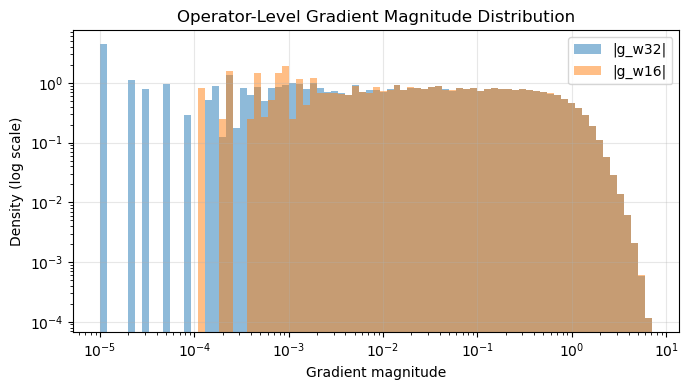

In [11]:
def _abs_nonzero_np(x, atol):
    x = _flatten_f32(x).numpy()
    a = np.abs(x)
    return a[a > atol]

abs32 = _abs_nonzero_np(g_w32, CONFIG['sign_atol'])
abs16 = _abs_nonzero_np(g_w16, CONFIG['sign_atol'])

plt.figure(figsize=(7, 4))
if abs32.size > 0 and abs16.size > 0:
    lo = min(abs32.min(), abs16.min())
    hi = max(abs32.max(), abs16.max())
    bins = np.logspace(np.log10(lo), np.log10(hi), 80)
    plt.hist(abs32, bins=bins, alpha=0.5, label='|g_w32|', density=True)
    plt.hist(abs16, bins=bins, alpha=0.5, label='|g_w16|', density=True)
    plt.xscale('log')
else:
    # Fallback for degenerate all-zero gradients
    plt.hist(_flatten_f32(g_w32).numpy(), bins=80, alpha=0.5, label='g_w32', density=True)
    plt.hist(_flatten_f32(g_w16).numpy(), bins=80, alpha=0.5, label='g_w16', density=True)

plt.yscale('log')
plt.xlabel('Gradient magnitude')
plt.ylabel('Density (log scale)')
plt.title('Operator-Level Gradient Magnitude Distribution')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()



In [12]:
print('Additional operator-level diagnostics:')
print('  rec_z grad connected fp32/fp16:', conn32[0], conn16[0])
print('  weight grad connected fp32/fp16:', conn32[1], conn16[1])
print('  cos(g_rec_z32, g_rec_z16):', cosine_sim(g_rec_z32, g_rec_z16))
print('  cos(g_w32, g_w16):', cosine_sim(g_w32, g_w16))
print('  rel_l2(g_w32, g_w16):', rel_l2(g_w32, g_w16))

if l2_norm(g_rec_z32) == 0.0 and l2_norm(g_rec_z16) == 0.0:
    print('  WARNING: both rec_z gradients are exactly zero in this probe. rec_z gradient comparison is inconclusive.')
if l2_norm(g_w16) == 0.0 and l2_norm(g_w32) > 0.0:
    print('  WARNING: fp16 weight gradient is zero while fp32 is nonzero (possible underflow/disconnect).')


Additional operator-level diagnostics:
  rec_z grad connected fp32/fp16: False False
  weight grad connected fp32/fp16: True True
  cos(g_rec_z32, g_rec_z16): nan
  cos(g_w32, g_w16): 1.0
  rel_l2(g_w32, g_w16): 0.00047032878501340747


## 2) BPTT Error Propagation Sweep

For each sequence length (truncation window), this computes gradients through full unroll and compares:
- forward drift (loss/voltage/spikes)
- recurrent-weight gradient drift
- gradient support overlap and sign consistency

It evaluates **two fp16 paths**:
1. `fp16_unscaled`: no loss scaling
2. `fp16_scaled`: fixed loss scaling (`CONFIG['fp16_loss_scale']`), approximating training practice



In [13]:
def bptt_pass(cell, x_bool, seq_len, alpha=1.0, beta=0.01, loss_scale=None):
    with tf.GradientTape() as tape:
        z, v, state = rollout(cell, x_bool, seq_len)
        loss = alpha * tf.reduce_mean(z) + beta * tf.reduce_mean(tf.square(v))
        if loss_scale is None:
            loss_for_grad = loss
        else:
            loss_for_grad = loss * tf.cast(loss_scale, loss.dtype)

    (g_w,), connected = gradient_with_status(
        tape,
        loss_for_grad,
        [cell.recurrent_weight_values],
    )

    if loss_scale is not None:
        g_w = g_w / tf.cast(loss_scale, tf.float32)

    z_bin = tf.cast(z > 0.5, tf.float32)

    return {
        'loss': tf.cast(loss, tf.float32),
        'z': z,
        'z_bin': z_bin,
        'v': v,
        'state': state,
        'g_w': g_w,
        'grad_connected': bool(connected[0]),
        'grad_norm': float(tf.norm(g_w)),
        'grad_nonzero_frac': float(tf.reduce_mean(tf.cast(tf.abs(g_w) > CONFIG['sign_atol'], tf.float32))),
        'spike_rate': float(tf.reduce_mean(z_bin)),
    }


def z_mismatch_rate(z_ref_bin, z_test_bin):
    return float(tf.reduce_mean(tf.cast(tf.not_equal(z_ref_bin, z_test_bin), tf.float32)))


def _resolve_viz_seq_len(seq_lens, requested=None):
    seq_lens = sorted(list(seq_lens))
    if requested is None:
        return seq_lens[-1]
    if requested in seq_lens:
        return requested
    smaller = [s for s in seq_lens if s <= requested]
    if smaller:
        return smaller[-1]
    return seq_lens[0]


viz_seq_len = _resolve_viz_seq_len(CONFIG['bptt_seq_lengths'], CONFIG.get('viz_seq_len', None))
bptt_visual_data = None

rows = []
for L in CONFIG['bptt_seq_lengths']:
    xL = x_bool[:, :L, :]

    ref = bptt_pass(cell32, xL, L, alpha=CONFIG['loss_alpha'], beta=CONFIG['loss_beta'], loss_scale=None)
    tst_unscaled = bptt_pass(cell16, xL, L, alpha=CONFIG['loss_alpha'], beta=CONFIG['loss_beta'], loss_scale=None)

    if CONFIG['evaluate_fp16_with_loss_scaling']:
        tst_scaled = bptt_pass(
            cell16,
            xL,
            L,
            alpha=CONFIG['loss_alpha'],
            beta=CONFIG['loss_beta'],
            loss_scale=CONFIG['fp16_loss_scale'],
        )
    else:
        tst_scaled = None

    cmp_unscaled = compare_tensors(ref['g_w'], tst_unscaled['g_w'], 'grad_w')

    if tst_scaled is not None:
        cmp_scaled = compare_tensors(ref['g_w'], tst_scaled['g_w'], 'grad_w')
    else:
        cmp_scaled = None

    row = {
        'seq_len': L,

        # Forward drift (fp16 unscaled path)
        'loss_fp32': float(ref['loss']),
        'loss_fp16_unscaled': float(tst_unscaled['loss']),
        'loss_abs_diff_unscaled': float(tf.abs(ref['loss'] - tst_unscaled['loss'])),
        'loss_rel_diff_unscaled': float(tf.abs(ref['loss'] - tst_unscaled['loss']) / tf.maximum(tf.abs(ref['loss']), CONFIG['rel_eps'])),
        'z_rel_l2_unscaled': rel_l2(ref['z'], tst_unscaled['z']),
        'v_rel_l2_unscaled': rel_l2(ref['v'], tst_unscaled['v']),
        'z_mismatch_rate_unscaled': z_mismatch_rate(ref['z_bin'], tst_unscaled['z_bin']),
        'final_z_state_rel_l2_unscaled': rel_l2(ref['state'][0], tst_unscaled['state'][0]),

        # Gradient connectivity/norms
        'grad_connected_fp32': ref['grad_connected'],
        'grad_connected_fp16_unscaled': tst_unscaled['grad_connected'],
        'grad_norm_fp32': ref['grad_norm'],
        'grad_norm_fp16_unscaled': tst_unscaled['grad_norm'],
        'grad_nonzero_frac_fp32': ref['grad_nonzero_frac'],
        'grad_nonzero_frac_fp16_unscaled': tst_unscaled['grad_nonzero_frac'],

        # Gradient comparison (unscaled)
        'grad_w_rel_l2_unscaled': cmp_unscaled['l2_rel'],
        'grad_w_cosine_unscaled': cmp_unscaled['cosine'],
        'grad_w_support_jaccard_unscaled': cmp_unscaled['support_jaccard'],
        'grad_w_sign_mismatch_union_unscaled': cmp_unscaled['sign_mismatch_union'],
        'grad_w_sign_mismatch_overlap_unscaled': cmp_unscaled['sign_mismatch_overlap'],
    }

    if cmp_scaled is not None:
        row.update({
            'loss_fp16_scaled': float(tst_scaled['loss']),
            'loss_rel_diff_scaled': float(tf.abs(ref['loss'] - tst_scaled['loss']) / tf.maximum(tf.abs(ref['loss']), CONFIG['rel_eps'])),
            'grad_connected_fp16_scaled': tst_scaled['grad_connected'],
            'grad_norm_fp16_scaled': tst_scaled['grad_norm'],
            'grad_nonzero_frac_fp16_scaled': tst_scaled['grad_nonzero_frac'],
            'grad_w_rel_l2_scaled': cmp_scaled['l2_rel'],
            'grad_w_cosine_scaled': cmp_scaled['cosine'],
            'grad_w_support_jaccard_scaled': cmp_scaled['support_jaccard'],
            'grad_w_sign_mismatch_union_scaled': cmp_scaled['sign_mismatch_union'],
            'grad_w_sign_mismatch_overlap_scaled': cmp_scaled['sign_mismatch_overlap'],
        })

    rows.append(row)

    if L == viz_seq_len:
        bptt_visual_data = {
            'seq_len': L,
            'z_fp32': tf.identity(ref['z']),
            'v_fp32': tf.identity(ref['v']),
            'z_fp16': tf.identity(tst_unscaled['z']),
            'v_fp16': tf.identity(tst_unscaled['v']),
        }

if bptt_visual_data is None:
    # Fallback: build visualization data using resolved viz_seq_len.
    xL = x_bool[:, :viz_seq_len, :]
    ref = bptt_pass(cell32, xL, viz_seq_len, alpha=CONFIG['loss_alpha'], beta=CONFIG['loss_beta'], loss_scale=None)
    tst_unscaled = bptt_pass(cell16, xL, viz_seq_len, alpha=CONFIG['loss_alpha'], beta=CONFIG['loss_beta'], loss_scale=None)
    bptt_visual_data = {
        'seq_len': viz_seq_len,
        'z_fp32': tf.identity(ref['z']),
        'v_fp32': tf.identity(ref['v']),
        'z_fp16': tf.identity(tst_unscaled['z']),
        'v_fp16': tf.identity(tst_unscaled['v']),
    }

bptt_df = pd.DataFrame(rows).sort_values('seq_len').reset_index(drop=True)
print('Visualization sequence length for traces/raster:', bptt_visual_data['seq_len'])
bptt_df



Visualization sequence length for traces/raster: 500


,seq_len,loss_fp32,loss_fp16_unscaled,loss_abs_diff_unscaled,loss_rel_diff_unscaled,z_rel_l2_unscaled,v_rel_l2_unscaled,z_mismatch_rate_unscaled,final_z_state_rel_l2_unscaled,grad_connected_fp32,...,loss_fp16_scaled,loss_rel_diff_scaled,grad_connected_fp16_scaled,grad_norm_fp16_scaled,grad_nonzero_frac_fp16_scaled,grad_w_rel_l2_scaled,grad_w_cosine_scaled,grad_w_support_jaccard_scaled,grad_w_sign_mismatch_union_scaled,grad_w_sign_mismatch_overlap_scaled
0,20,0.004287,0.004250,0.000037,0.008599,0.212380,0.028625,0.000101,0.374437,True,...,0.004250,0.008607,True,0.000016,0.138853,0.067015,0.997763,0.991751,0.004265,0.001151
1,500,0.006815,0.006822,0.000007,0.000993,1.217848,0.213573,0.004541,1.250878,True,...,0.006813,0.000372,True,0.000070,0.325242,0.068925,0.997623,0.916397,0.079814,0.010271


Average per-neuron MAE: 0.07030362


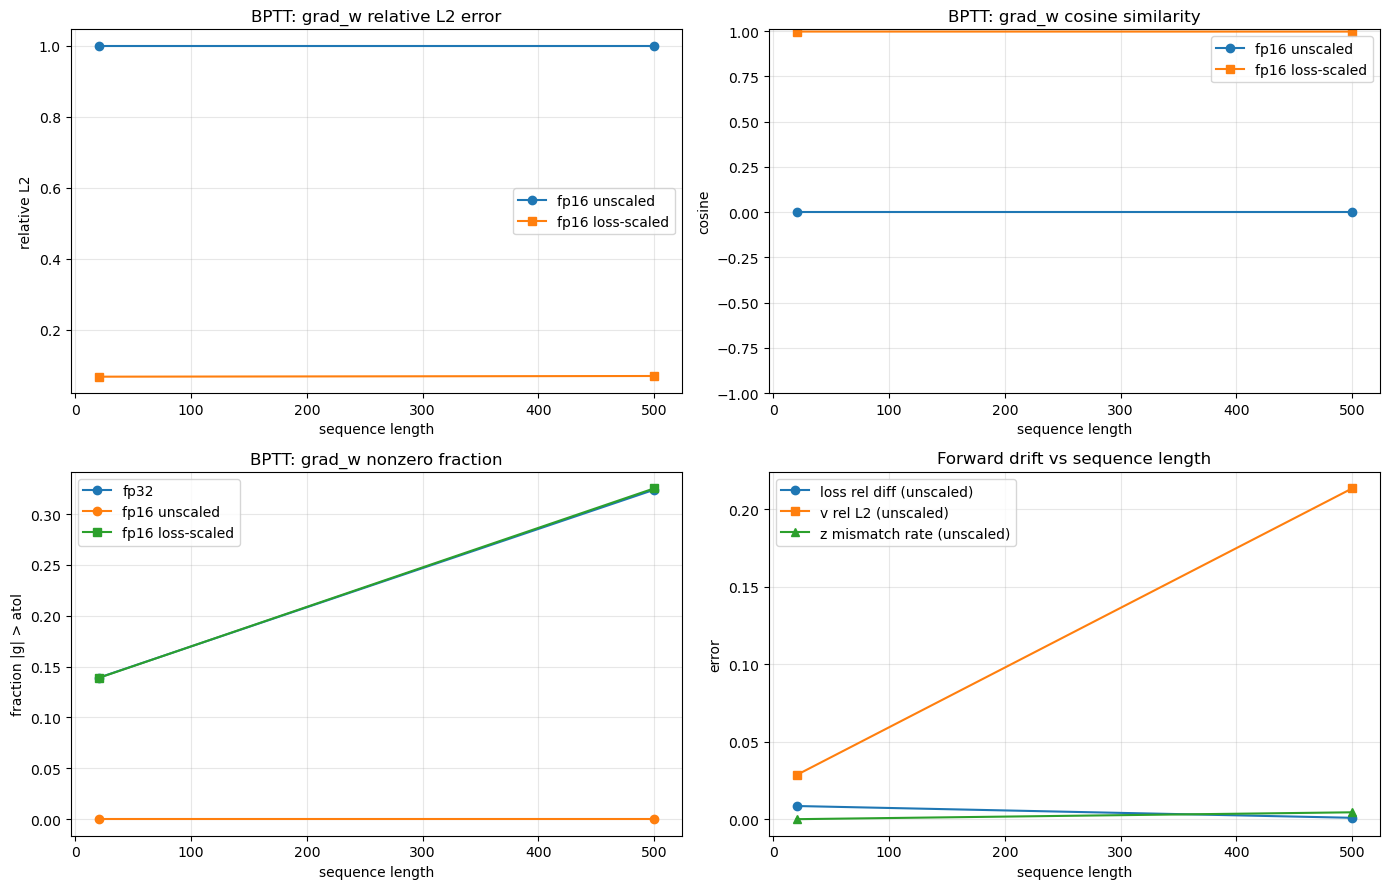

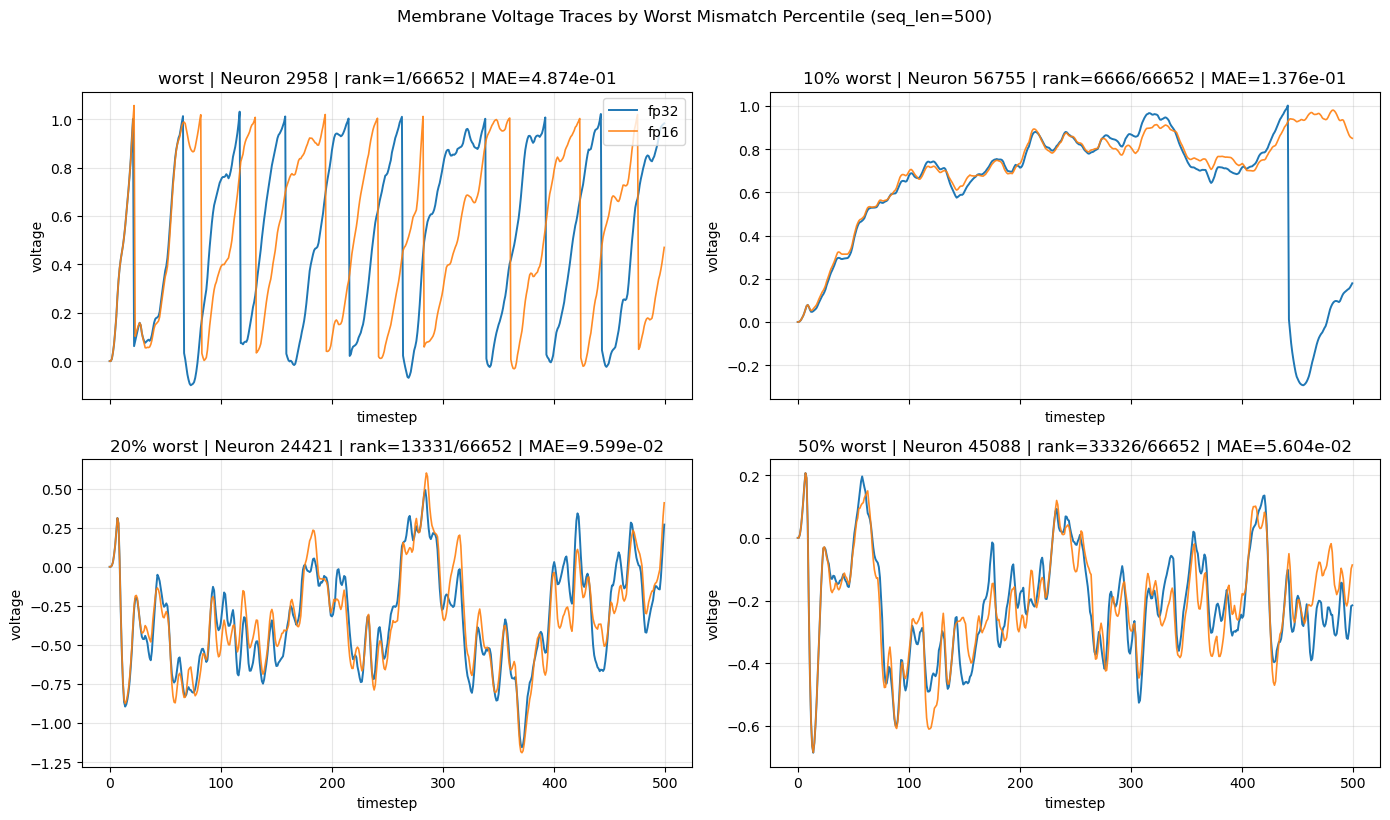

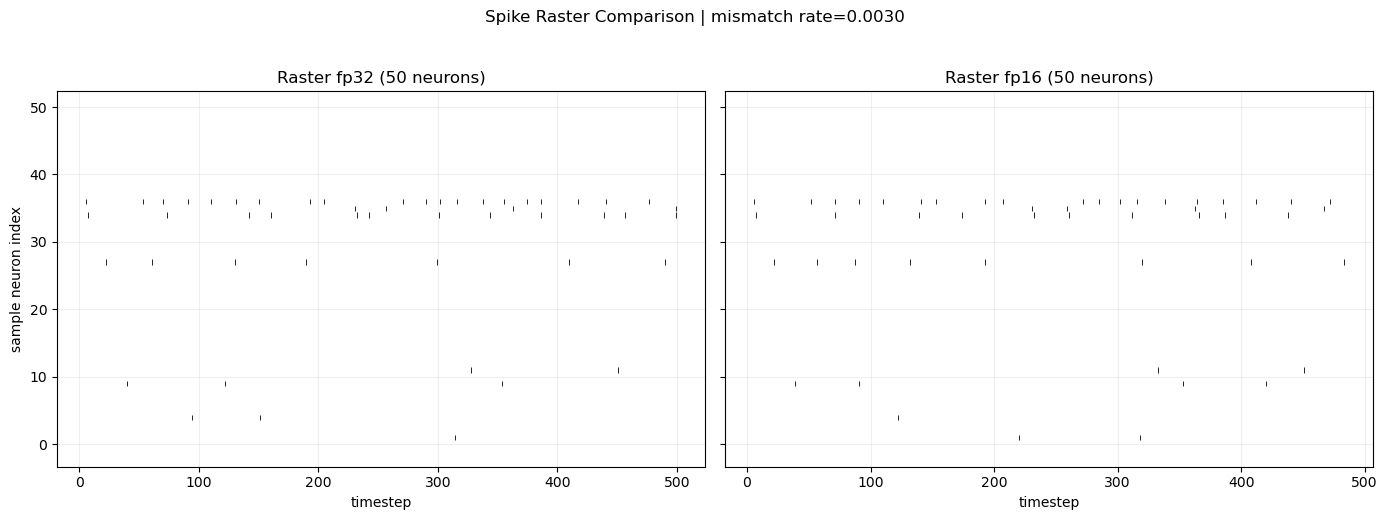

In [14]:
fig, ax = plt.subplots(2, 2, figsize=(14, 9))

# 1) Gradient relative error
ax[0, 0].plot(bptt_df['seq_len'], bptt_df['grad_w_rel_l2_unscaled'], marker='o', label='fp16 unscaled')
if 'grad_w_rel_l2_scaled' in bptt_df.columns:
    ax[0, 0].plot(bptt_df['seq_len'], bptt_df['grad_w_rel_l2_scaled'], marker='s', label='fp16 loss-scaled')
ax[0, 0].set_title('BPTT: grad_w relative L2 error')
ax[0, 0].set_xlabel('sequence length')
ax[0, 0].set_ylabel('relative L2')
ax[0, 0].grid(True, alpha=0.3)
ax[0, 0].legend()

# 2) Gradient cosine similarity
ax[0, 1].plot(bptt_df['seq_len'], bptt_df['grad_w_cosine_unscaled'], marker='o', label='fp16 unscaled')
if 'grad_w_cosine_scaled' in bptt_df.columns:
    ax[0, 1].plot(bptt_df['seq_len'], bptt_df['grad_w_cosine_scaled'], marker='s', label='fp16 loss-scaled')
ax[0, 1].set_title('BPTT: grad_w cosine similarity')
ax[0, 1].set_xlabel('sequence length')
ax[0, 1].set_ylabel('cosine')
ax[0, 1].set_ylim([-1.0, 1.01])
ax[0, 1].grid(True, alpha=0.3)
ax[0, 1].legend()

# 3) Gradient sparsity / underflow proxy
ax[1, 0].plot(bptt_df['seq_len'], bptt_df['grad_nonzero_frac_fp32'], marker='o', label='fp32')
ax[1, 0].plot(bptt_df['seq_len'], bptt_df['grad_nonzero_frac_fp16_unscaled'], marker='o', label='fp16 unscaled')
if 'grad_nonzero_frac_fp16_scaled' in bptt_df.columns:
    ax[1, 0].plot(bptt_df['seq_len'], bptt_df['grad_nonzero_frac_fp16_scaled'], marker='s', label='fp16 loss-scaled')
ax[1, 0].set_title('BPTT: grad_w nonzero fraction')
ax[1, 0].set_xlabel('sequence length')
ax[1, 0].set_ylabel('fraction |g| > atol')
ax[1, 0].grid(True, alpha=0.3)
ax[1, 0].legend()

# 4) Forward drift
ax[1, 1].plot(bptt_df['seq_len'], bptt_df['loss_rel_diff_unscaled'], marker='o', label='loss rel diff (unscaled)')
ax[1, 1].plot(bptt_df['seq_len'], bptt_df['v_rel_l2_unscaled'], marker='s', label='v rel L2 (unscaled)')
ax[1, 1].plot(bptt_df['seq_len'], bptt_df['z_mismatch_rate_unscaled'], marker='^', label='z mismatch rate (unscaled)')
ax[1, 1].set_title('Forward drift vs sequence length')
ax[1, 1].set_xlabel('sequence length')
ax[1, 1].set_ylabel('error')
ax[1, 1].grid(True, alpha=0.3)
ax[1, 1].legend()

plt.tight_layout()


# ----- Requested visual comparisons: voltage traces and raster -----
def _sample_neuron_ids(n_neurons, n_pick, seed):
    n_pick = min(int(n_pick), int(n_neurons))
    rng = np.random.default_rng(seed)
    return np.sort(rng.choice(n_neurons, size=n_pick, replace=False))

v32 = bptt_visual_data['v_fp32'][0].numpy()  # [T, N]
v16 = bptt_visual_data['v_fp16'][0].numpy()  # [T, N]
z32 = bptt_visual_data['z_fp32'][0].numpy()  # [T, N]
z16 = bptt_visual_data['z_fp16'][0].numpy()  # [T, N]

n_neurons = v32.shape[1]
# Select neurons by mismatch severity: worst, 10%, 20%, 50% worst
per_neuron_mae = np.mean(np.abs(v32 - v16), axis=0)
print('Average per-neuron MAE:', np.mean(per_neuron_mae))
sorted_idx = np.argsort(per_neuron_mae)[::-1]  # descending mismatch

labels = ['worst', '10% worst', '20% worst', '50% worst']
fractions = [0.0, 0.10, 0.20, 0.5]
trace_neurons = []
trace_meta = []
for label, frac in zip(labels, fractions):
    rank = int(np.ceil(frac * n_neurons))
    rank = min(max(rank, 1), n_neurons) - 1  # convert to 0-based rank
    nid = int(sorted_idx[rank])
    trace_neurons.append(nid)
    trace_meta.append((label, rank + 1, float(per_neuron_mae[nid])))

# 4-panel membrane voltage traces
# trace_neurons = [172, 572, 385, 160]
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
t = np.arange(v32.shape[0])
for idx, ax in enumerate(axes.flat):
    if idx >= len(trace_neurons):
        ax.axis('off')
        continue
    nid = trace_neurons[idx]
    mae = per_neuron_mae[nid]
    label, rank, _ = trace_meta[idx]
    ax.plot(t, v32[:, nid], lw=1.4, color='tab:blue', label='fp32')
    ax.plot(t, v16[:, nid], lw=1.2, color='tab:orange', alpha=0.9, label='fp16')
    ax.set_title(f'{label} | Neuron {nid} | rank={rank}/{n_neurons} | MAE={mae:.3e}')
    ax.set_xlabel('timestep')
    ax.set_ylabel('voltage')
    ax.grid(True, alpha=0.3)

axes[0, 0].legend(loc='upper right')
fig.suptitle(f'Membrane Voltage Traces by Worst Mismatch Percentile (seq_len={bptt_visual_data["seq_len"]})', y=1.02)
plt.tight_layout()

# Raster plots: same 50 neurons for fp32 and fp16
raster_neurons = _sample_neuron_ids(n_neurons, 50, seed=CONFIG['seed'] + 999)
z32_sub = (z32[:, raster_neurons] > 0.5)
z16_sub = (z16[:, raster_neurons] > 0.5)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

events32 = [np.where(z32_sub[:, i])[0] for i in range(z32_sub.shape[1])]
events16 = [np.where(z16_sub[:, i])[0] for i in range(z16_sub.shape[1])]

ax1.eventplot(events32, colors='black', linewidths=0.6, linelengths=0.8)
ax1.set_title(f'Raster fp32 ({len(raster_neurons)} neurons)')
ax1.set_xlabel('timestep')
ax1.set_ylabel('sample neuron index')
ax1.grid(True, alpha=0.2)

ax2.eventplot(events16, colors='black', linewidths=0.6, linelengths=0.8)
ax2.set_title(f'Raster fp16 ({len(raster_neurons)} neurons)')
ax2.set_xlabel('timestep')
ax2.grid(True, alpha=0.2)

raster_mismatch = np.mean(z32_sub != z16_sub)
fig.suptitle(f'Spike Raster Comparison | mismatch rate={raster_mismatch:.4f}', y=1.03)
plt.tight_layout()

In [ ]:
# Average per-neuron MAE: 0.0442873 (1k, v fp32, current fp16)
# Average per-neuron MAE: 0.044713046 (1k, v fp16, current fp16)
# Average per-neuron MAE: 0.045095466 (1k, v fp16, current fp32)

In [ ]:
# Average per-neuron MAE: 0.069663656 (66k, with float16 v and r, but fp16 currents and fp32 threshold determination)
# Average per-neuron MAE: 0.06885541 (66k, with float16 v and r, but fp32 currents and fp32 threshold determination)
# Average per-neuron MAE: 0.07078617 (66k, with float16 v and r, fp16 currents)
# Average per-neuron MAE: 0.07011654 (66k, with float32 v and r, fp32 currents)
# Average per-neuron MAE: 0.07454746 (66k, with float32 v and r, fp16 currents)
# Average per-neuron MAE: 0.07136048 (66k, with float32 v, but fp16 currents)

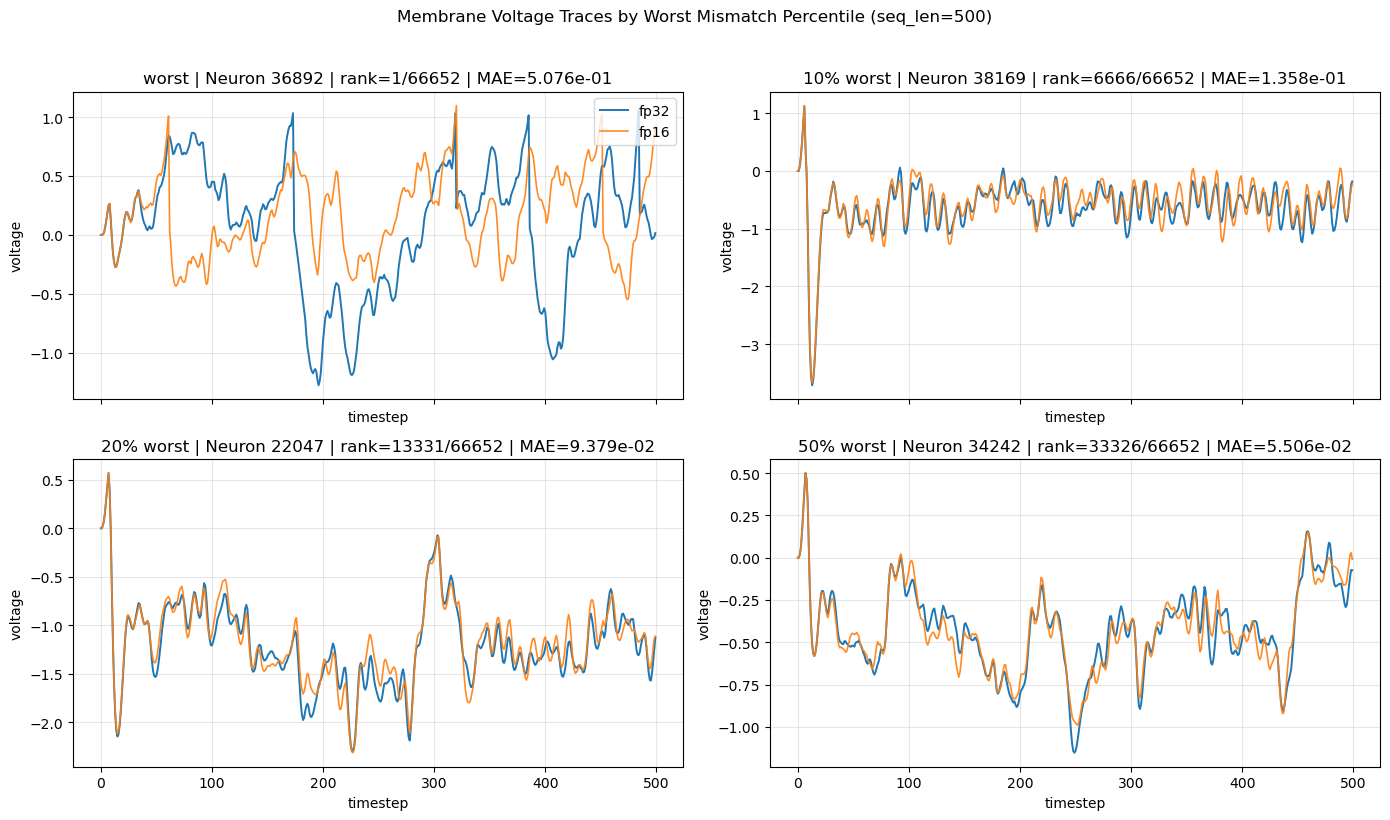

In [ ]:
# Select neurons by mismatch severity: worst, 10%, 20%, 50% worst
per_neuron_mae = np.mean(np.abs(v32 - v16), axis=0)
sorted_idx = np.argsort(per_neuron_mae)[::-1]  # descending mismatch

labels = ['worst', '10% worst', '20% worst', '50% worst']
fractions = [0.0, 0.10, 0.20, 0.50]
trace_neurons = []
trace_meta = []
for label, frac in zip(labels, fractions):
    rank = int(np.ceil(frac * n_neurons))
    rank = min(max(rank, 1), n_neurons) - 1  # convert to 0-based rank
    nid = int(sorted_idx[rank])
    trace_neurons.append(nid)
    trace_meta.append((label, rank + 1, float(per_neuron_mae[nid])))

# 4-panel membrane voltage traces
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
t = np.arange(v32.shape[0])
for idx, ax in enumerate(axes.flat):
    if idx >= len(trace_neurons):
        ax.axis('off')
        continue
    nid = trace_neurons[idx]
    label, rank, mae = trace_meta[idx]
    ax.plot(t, v32[:, nid], lw=1.4, color='tab:blue', label='fp32')
    ax.plot(t, v16[:, nid], lw=1.2, color='tab:orange', alpha=0.9, label='fp16')
    ax.set_title(f'{label} | Neuron {nid} | rank={rank}/{n_neurons} | MAE={mae:.3e}')
    ax.set_xlabel('timestep')
    ax.set_ylabel('voltage')
    ax.grid(True, alpha=0.3)

axes[0, 0].legend(loc='upper right')
fig.suptitle(f'Membrane Voltage Traces by Worst Mismatch Percentile (seq_len={bptt_visual_data["seq_len"]})', y=1.02)
plt.tight_layout()


## How To Interpret

- `grad_connected_*` tells you if the gradient path is truly connected (before any zero fallback).
- If `grad_w_rel_l2_unscaled` is large and `grad_nonzero_frac_fp16_unscaled` collapses, that is consistent with fp16 underflow.
- Compare unscaled vs scaled columns: if scaling restores cosine/support and lowers rel-L2, training-time loss scaling is mitigating the issue.
- `z_mismatch_rate_unscaled` is often more interpretable than `z_rel_l2_unscaled` for sparse spikes.
- `support_jaccard` and `sign_mismatch_overlap` avoid over-penalizing exact zeros compared to a single global sign-mismatch score.
- `cosine = NaN` means both vectors are zero (non-informative), not disagreement.

To match your real training setup more closely:
1. Set `CONFIG['input_mode'] = 'spontaneous_cached'` if cached probability files are available.
2. Replace probe loss with your true training objective terms (rate, voltage, OSI/DSI, regularizers).
3. Keep `CONFIG['evaluate_fp16_with_loss_scaling'] = True` to mirror float16 training practice.



## 3) BPTT State-Gradient Probe (`g_rec`)

This section measures BPTT gradient parity for the recurrent spike-buffer state (`z_buf`) at selected timesteps.

Why targeted taps instead of every step:
- full per-step state-gradient capture is extremely expensive on this model size
- `t = 0`, `t = L/2`, and `t = L` capture early/mid/late propagation behavior with manageable memory

Compared paths:
- fp32 reference
- fp16 unscaled
- fp16 loss-scaled (fixed scale from `CONFIG['fp16_loss_scale']`)



In [ ]:
# Config for state-gradient probe
STATE_GRAD_CONFIG = {
    # If None, uses CONFIG['bptt_seq_lengths']
    'seq_lens': None,
    # Tap positions as fractions of sequence length; 0 and L are added explicitly
    'tap_fractions': [0.5],
    # Keep terminal state for diagnostics, but it is usually unconnected to this loss.
    'include_terminal_state_tap': True,
}


def _tap_steps_for_len(seq_len, tap_fractions, include_terminal_state_tap=True):
    taps = {0}
    if include_terminal_state_tap:
        taps.add(seq_len)
    for frac in tap_fractions:
        t = int(round(frac * seq_len))
        t = max(0, min(seq_len, t))
        taps.add(t)
    return sorted(taps)


def rollout_with_state_taps(cell, x_bool, seq_len, tap_steps, tape=None):
    """Roll out and optionally watch/capture z_buf state at selected steps.

    Step convention:
    - step 0: initial state before first input timestep
    - step k (k>=1): state after consuming timestep k-1
    """
    state = cell.zero_state(CONFIG['batch_size'], dtype=cell.compute_dtype)
    z_list, v_list = [], []

    taps = {}
    if 0 in tap_steps:
        taps[0] = state[0]
        if tape is not None:
            tape.watch(taps[0])

    for t in range(seq_len):
        out, state = cell(x_bool[:, t, :], state)
        z_list.append(tf.cast(out[0], tf.float32))
        v_list.append(tf.cast(state[1], tf.float32))

        step_idx = t + 1
        if step_idx in tap_steps:
            taps[step_idx] = state[0]
            if tape is not None:
                tape.watch(taps[step_idx])

    z = tf.stack(z_list, axis=1)
    v = tf.stack(v_list, axis=1)
    return z, v, state, taps


def bptt_state_grad_pass(cell, x_bool, seq_len, tap_steps, alpha=1.0, beta=0.01, loss_scale=None):
    with tf.GradientTape() as tape:
        z, v, state, taps = rollout_with_state_taps(cell, x_bool, seq_len, tap_steps, tape=tape)
        loss = alpha * tf.reduce_mean(z) + beta * tf.reduce_mean(tf.square(v))
        if loss_scale is None:
            loss_for_grad = loss
        else:
            loss_for_grad = loss * tf.cast(loss_scale, loss.dtype)

    ordered_steps = sorted(taps.keys())
    sources = [taps[s] for s in ordered_steps]
    grads, connected = gradient_with_status(tape, loss_for_grad, sources)

    if loss_scale is not None:
        grads = [g / tf.cast(loss_scale, tf.float32) for g in grads]

    grads_by_step = {s: g for s, g in zip(ordered_steps, grads)}
    connected_by_step = {s: bool(c) for s, c in zip(ordered_steps, connected)}

    return {
        'loss': tf.cast(loss, tf.float32),
        'z': z,
        'v': v,
        'state': state,
        'grads_by_step': grads_by_step,
        'connected_by_step': connected_by_step,
        'tap_steps': ordered_steps,
    }


seq_lens = STATE_GRAD_CONFIG['seq_lens'] if STATE_GRAD_CONFIG['seq_lens'] is not None else CONFIG['bptt_seq_lengths']
rows = []

for L in seq_lens:
    xL = x_bool[:, :L, :]
    tap_steps = _tap_steps_for_len(
        L,
        STATE_GRAD_CONFIG['tap_fractions'],
        include_terminal_state_tap=STATE_GRAD_CONFIG['include_terminal_state_tap'],
    )

    ref = bptt_state_grad_pass(
        cell32, xL, L, tap_steps,
        alpha=CONFIG['loss_alpha'],
        beta=CONFIG['loss_beta'],
        loss_scale=None,
    )

    fp16_unscaled = bptt_state_grad_pass(
        cell16, xL, L, tap_steps,
        alpha=CONFIG['loss_alpha'],
        beta=CONFIG['loss_beta'],
        loss_scale=None,
    )

    if CONFIG['evaluate_fp16_with_loss_scaling']:
        fp16_scaled = bptt_state_grad_pass(
            cell16, xL, L, tap_steps,
            alpha=CONFIG['loss_alpha'],
            beta=CONFIG['loss_beta'],
            loss_scale=CONFIG['fp16_loss_scale'],
        )
    else:
        fp16_scaled = None

    for step in tap_steps:
        ref_g = ref['grads_by_step'][step]

        unscaled_cmp = compare_tensors(ref_g, fp16_unscaled['grads_by_step'][step], f'g_rec_step_{step}')
        rows.append({
            'seq_len': L,
            'tap_step': step,
            'tap_frac': step / float(L) if L > 0 else 0.0,
            'path': 'fp16_unscaled',
            'ref_connected': ref['connected_by_step'][step],
            'test_connected': fp16_unscaled['connected_by_step'][step],
            'comparison_valid': bool(ref['connected_by_step'][step] and fp16_unscaled['connected_by_step'][step]),
            'ref_grad_norm': l2_norm(ref_g),
            'test_grad_norm': l2_norm(fp16_unscaled['grads_by_step'][step]),
            **{k: v for k, v in unscaled_cmp.items() if k != 'tensor'},
        })

        if fp16_scaled is not None:
            scaled_cmp = compare_tensors(ref_g, fp16_scaled['grads_by_step'][step], f'g_rec_step_{step}')
            rows.append({
                'seq_len': L,
                'tap_step': step,
                'tap_frac': step / float(L) if L > 0 else 0.0,
                'path': 'fp16_scaled',
                'ref_connected': ref['connected_by_step'][step],
                'test_connected': fp16_scaled['connected_by_step'][step],
                'comparison_valid': bool(ref['connected_by_step'][step] and fp16_scaled['connected_by_step'][step]),
                'ref_grad_norm': l2_norm(ref_g),
                'test_grad_norm': l2_norm(fp16_scaled['grads_by_step'][step]),
                **{k: v for k, v in scaled_cmp.items() if k != 'tensor'},
            })

state_grad_df = pd.DataFrame(rows).sort_values(['seq_len', 'tap_step', 'path']).reset_index(drop=True)
state_grad_df



,seq_len,tap_step,tap_frac,path,ref_connected,test_connected,comparison_valid,ref_grad_norm,test_grad_norm,ref_l2_norm,...,frac_zero_after_fp16_cast,frac_ref_nonzero_lost_to_fp16_zero,both_zero,ref_nonzero_frac,test_nonzero_frac,support_jaccard,support_recall,support_precision,sign_mismatch_overlap,sign_mismatch_union
0,20,0,0.0,fp16_scaled,True,True,True,0.000036,0.000036,0.000036,...,0.735722,0.462947,False,0.721854,0.722059,0.995776,0.998025,0.997742,0.001166,0.001707
1,20,0,0.0,fp16_unscaled,True,True,True,0.000036,0.000023,0.000036,...,0.735722,0.462947,False,0.721854,0.093491,0.129428,0.129438,0.999412,0.158861,0.891098
2,20,10,0.5,fp16_scaled,True,True,True,0.000033,0.000033,0.000033,...,0.793175,0.520400,False,0.703510,0.703815,0.990697,0.995543,0.995111,0.002721,0.004549
3,20,10,0.5,fp16_unscaled,True,True,True,0.000033,0.000018,0.000033,...,0.793175,0.520400,False,0.703510,0.039214,0.055732,0.055733,0.999872,0.052168,0.947168
4,20,20,1.0,fp16_scaled,False,False,False,0.000000,0.000000,0.000000,...,1.000000,0.000000,True,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000
5,20,20,1.0,fp16_unscaled,False,False,False,0.000000,0.000000,0.000000,...,1.000000,0.000000,True,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000
6,500,0,0.0,fp16_scaled,True,True,True,0.000003,0.000003,0.000003,...,0.996559,0.723784,False,0.642316,0.643747,0.990649,0.996411,0.994197,0.001321,0.002965
7,500,0,0.0,fp16_unscaled,True,True,True,0.000003,0.000000,0.000003,...,0.996559,0.723784,False,0.642316,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000
8,500,250,0.5,fp16_scaled,True,True,True,0.000005,0.000005,0.000005,...,0.979650,0.706876,False,0.670548,0.672258,0.973423,0.987791,0.985278,0.011545,0.016331
9,500,250,0.5,fp16_unscaled,True,True,True,0.000005,0.000000,0.000005,...,0.979650,0.706876,False,0.670548,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000


Valid rows: 8 out of 12


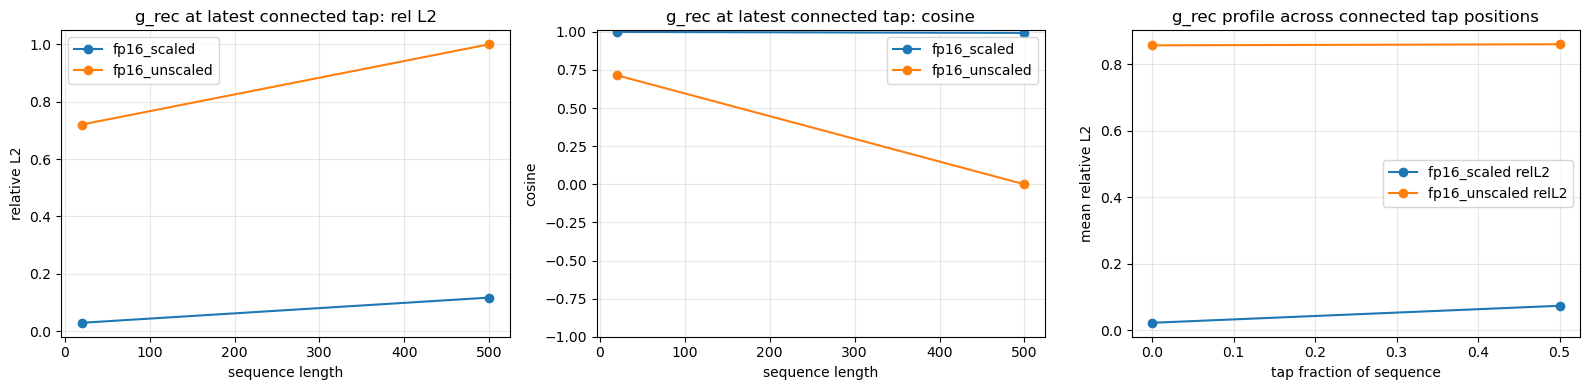

In [ ]:
# Visual summary for state-gradient parity
if len(state_grad_df) == 0:
    print('state_grad_df is empty; run the previous cell first.')
else:
    # Keep only connected comparisons for quantitative parity plots.
    valid_df = state_grad_df[state_grad_df['comparison_valid']].copy()
    print('Valid rows:', len(valid_df), 'out of', len(state_grad_df))

    if len(valid_df) == 0:
        print('No connected state-gradient comparisons available.')
    else:
        fig, ax = plt.subplots(1, 3, figsize=(16, 4))

        # For each seq_len/path, pick the latest connected tap (max tap_frac)
        latest_rows = []
        for (path_name, seq_len), g in valid_df.groupby(['path', 'seq_len']):
            latest_rows.append(g.loc[g['tap_frac'].idxmax()])
        latest_df = pd.DataFrame(latest_rows)

        for path_name in sorted(latest_df['path'].unique()):
            p = latest_df[latest_df['path'] == path_name].sort_values('seq_len')
            ax[0].plot(p['seq_len'], p['l2_rel'], marker='o', label=path_name)
        ax[0].set_title('g_rec at latest connected tap: rel L2')
        ax[0].set_xlabel('sequence length')
        ax[0].set_ylabel('relative L2')
        ax[0].grid(True, alpha=0.3)
        ax[0].legend()

        for path_name in sorted(latest_df['path'].unique()):
            p = latest_df[latest_df['path'] == path_name].sort_values('seq_len')
            ax[1].plot(p['seq_len'], p['cosine'], marker='o', label=path_name)
        ax[1].set_title('g_rec at latest connected tap: cosine')
        ax[1].set_xlabel('sequence length')
        ax[1].set_ylabel('cosine')
        ax[1].set_ylim([-1.0, 1.01])
        ax[1].grid(True, alpha=0.3)
        ax[1].legend()

        prof = valid_df.groupby(['tap_frac', 'path'], as_index=False).agg(
            l2_rel_mean=('l2_rel', 'mean'),
            cosine_mean=('cosine', 'mean'),
        )
        for path_name in sorted(prof['path'].unique()):
            p = prof[prof['path'] == path_name].sort_values('tap_frac')
            ax[2].plot(p['tap_frac'], p['l2_rel_mean'], marker='o', label=f'{path_name} relL2')
        ax[2].set_title('g_rec profile across connected tap positions')
        ax[2].set_xlabel('tap fraction of sequence')
        ax[2].set_ylabel('mean relative L2')
        ax[2].grid(True, alpha=0.3)
        ax[2].legend()

        plt.tight_layout()


### Reading This Section

- `ref_connected`/`test_connected` indicate whether each tapped state tensor had an actual gradient path.
- Use `comparison_valid=True` rows for quantitative parity; `False` rows are diagnostic only.
- Terminal taps (`tap_frac=1.0`) are often unconnected for this loss and should not be used for parity conclusions.
- For sparse state-gradients, prioritize `support_jaccard` and `sign_mismatch_overlap` over raw union sign mismatch.
- If `fp16_scaled` is substantially better than `fp16_unscaled`, the main issue is likely gradient dynamic range (underflow), not forward precision alone.

